# 1. 项目背景
在日常观看 MLB 比赛时，投手的表现往往通过 ERA、胜负数或少数几项传统数据来评价，但这些指标很难完整反映不同投手在三振、保送、投球稳定性等方面的真实差异。即使在同一个赛季，不同类型投手之间的表现分布也存在明显差别。 本项目选取 Baseball-Reference 提供的 2025 赛季 MLB 投手赛季数据，对投手的基础统计指标进行整理与分析。分析内容主要集中在表面数据层面，包括出场情况、投球局数、三振与保送、ERA / FIP 等常见指标，目的是直观地了解 2025 赛季投手整体表现的分布情况，以及不同投手之间的差异。 本 Notebook 更偏向于数据整理与探索性分析，不涉及复杂建模或逐球层面的研究，重点在于通过简单清晰的统计方法，对当季投手数据形成一个整体认识。

# 2. 数据来源与说明

本项目使用的数据来自 Baseball-Reference，包含 2025 赛季 MLB 投手的常规赛赛季汇总数据。数据以 Excel 格式保存，并在本 Notebook 中进行读取与处理。


In [3]:
import pandas as pd
df = pd.read_excel('pitchers2025regular.xlsx')

# 3.数据清洗
需要注意的是，Baseball-Reference 中的投球局数（IP）采用棒球记法，例如 5.1 表示 5 又 1/3 局，5.2 表示 5 又 2/3 局。这种表示方式在表面上是小数，但并不符合标准的十进制数值含义，若直接用于加总或比较，容易产生计算错误。

因此，在后续分析前，先将投球局数统一转换为「出局数（outs）」这一整数形式进行存储。1 局等于 3 个出局数，这样可以避免小数表示带来的歧义。在需要展示或阅读时，再将出局数转换回常见的 IP 记法。

将原始的 IP 字段转换为对应的出局数。K% 定义为三振数占面对打者总数的比例，用于衡量投手的直接压制能力。
检查空值,保证ERA,IP等重要数据里没有空值


In [4]:
def ip_to_outs(IP):
    whole = int(IP)
    frac = round(IP - whole, 1)
    return whole * 3 + int(frac * 10)

def outs_to_ip(outs):
    return outs // 3 + (outs % 3) / 10

df['outs'] = df['IP'].apply(ip_to_outs)
df['K_Percentage'] = (df['SO'] / df['BF'] * 100).round(1)
df['BB_Percentage'] = (df['BB'] / df['BF'] * 100).round(1)

df.isna().sum()

Rk                     0
Player                 0
Age                    0
Team                   0
Lg                     0
WAR                    0
W                      0
L                      0
W-L%                 213
ERA                    0
G                      0
GS                     0
GF                     0
CG                     0
SHO                    0
SV                     0
IP                     0
H                      0
R                      0
ER                     0
HR                     0
BB                     0
IBB                    0
SO                     0
HBP                    0
BK                     0
WP                     0
BF                     0
ERA+                  46
FIP                    0
WHIP                   0
H9                     0
HR9                    0
BB9                    0
SO9                    0
SO/BB                 50
Awards               820
Player-additional      0
outs                   0
K_Percentage           0


# 4.描述统计
 K-BB% = 三振率（K%） − 保送率（BB%）
表示：投手在所有面对打者中，“多制造了多少三振、少给了多少保送”。
将K-BB%作为新的一列,分组区间并非联盟官方定义，而是用于描述性分析，便于比较不同压制能力层级投手的分布情况。

将小于12的定义为tier_1,

12~18的定义为tier_2,

18~22定义为tier_3,

大于22的定义为tier_4


In [5]:
df['K-BB_percentage'] = df['K_Percentage'] - df['BB_Percentage']
bins = [0,12,18,22,30]
labels = ['tier_1', 'tier_2', 'tier_3', 'tier_4']
df['K-BB_tier'] = pd.cut(
    df['K-BB_percentage'],
    bins= bins,
    labels= labels,
    right= False
)

## 筛选出先发投手
将投了140局的投手定义为先发投手

## 筛选出后援投手
将没有先发过,且投过的局数至少为3局的投手定义为后援投手

In [6]:
df_starter = df[df['outs'] >= 140 * 3].copy()

df_bullpen = df[(df['GS'] == 0) & (df['outs'] >= 3 * 3)].copy()

# 5.核心分析
##计算ERA和K-BB%的线性关系
##计算FIP和K-BB%的线性关系

ERA与FIP这两个指标均与K-BB%存在着线性关系,且先发的ERA和K-BB%的线性关系大于牛棚的线性关系,同一类型投手中FIP与K-BB%的线性关系大于ERA和K-BB%的线性关系

特别是先发投手,线性关系较强,但是牛棚只能算是中等相关


In [7]:
df_starter['ERA'].corr(df_starter['K-BB_percentage'])

np.float64(-0.6819514317355315)

In [8]:
df_starter['FIP'].corr(df_starter['K-BB_percentage'])

np.float64(-0.7894725292189281)

In [9]:
df_bullpen['ERA'].corr(df_bullpen['K-BB_percentage'])

np.float64(-0.4290569231227564)

In [10]:
df_bullpen['FIP'].corr(df_bullpen['K-BB_percentage'])

np.float64(-0.5533115887621834)

# 6.可视化
### 将ERA和K-BB%之间对比,画散点图
### 将FIP和K-BB%之间对比,画散点图

<Axes: xlabel='K-BB_percentage', ylabel='ERA'>

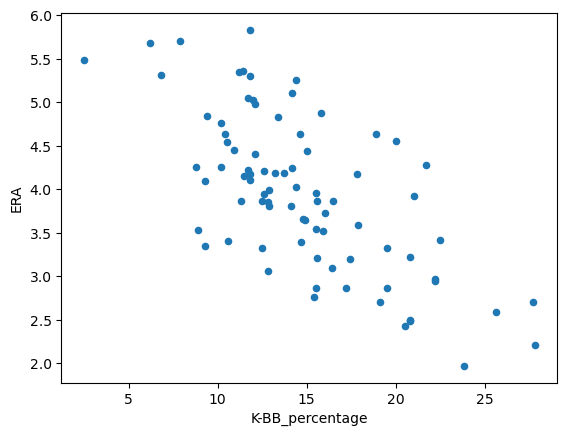

In [11]:
df_starter.plot(x='K-BB_percentage', y='ERA', kind='scatter')

<Axes: xlabel='K-BB_percentage', ylabel='FIP'>

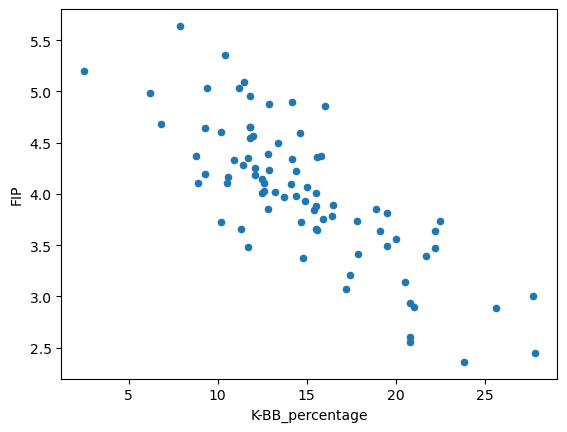

In [12]:
df_starter.plot(x='K-BB_percentage', y='FIP', kind='scatter')

<Axes: xlabel='K-BB_percentage', ylabel='ERA'>

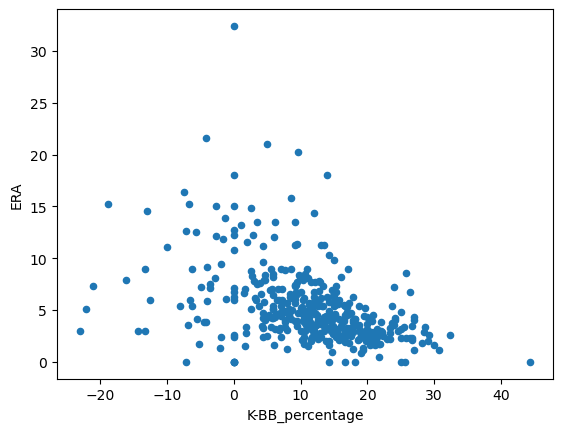

In [13]:
df_bullpen.plot(x='K-BB_percentage', y='ERA', kind='scatter')


<Axes: xlabel='K-BB_percentage', ylabel='FIP'>

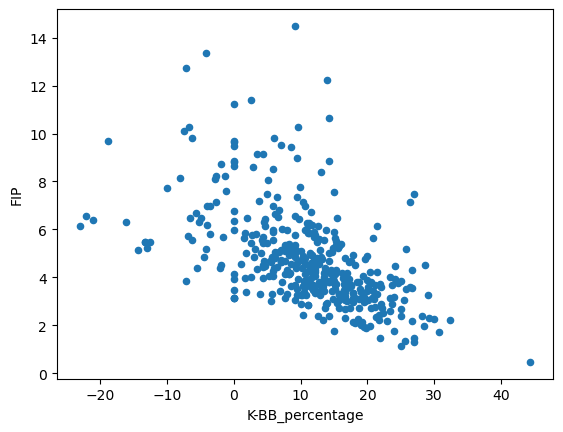

In [14]:
df_bullpen.plot(x='K-BB_percentage', y='FIP', kind='scatter')

ERA与K-BB_percentage的散点图中有一点明显偏离,先发投手中没有像这种程度的偏离
这位是捕手,比分差距过大时上去节约牛棚的,不愧是投手最好的伙伴

本分析基于赛季汇总数据，未区分对手强度、主客场及防守因素，结论仅适用于描述性比较。

In [15]:
df_bullpen[df_bullpen['ERA']>30]

,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,BB9,SO9,SO/BB,Awards,Player-additional,outs,K_Percentage,BB_Percentage,K-BB_percentage,K-BB_tier
766,767,Tyler Heineman,34,TOR,AL,-0.4,0,0,NaN,32.4,...,0.0,0.0,NaN,NaN,heinety01,10,0.0,0.0,0.0,tier_1
